In [3]:
%pip install matplotlib seaborn scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 43.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 35.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 28.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 27.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.0 MB/s  0:00:02m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]3/14 [seaborn]els]]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

final_clean = pd.read_csv('final_clean.csv')
print(final_clean.shape)
final_clean.head()

(468, 24)


,PULocationID,service,total_trips,avg_tip,avg_tip_rate,pct_tipped,LocationID,zone,borough,nta2020,...,pct_drive_alone,pct_public_transit,pct_white_collar,median_hh_income,per_capita_income,pct_poverty,avg_household_size,pct_no_hs_diploma,pct_bachelors_plus,pct_foreign_born
0,70,Lyft,169657,0.978312,0.035528,15.936861,70.0,East Elmhurst,Queens,QN0302,...,33.7,48.3,26.3,81328.0,28315.0,14.0,3.39,22.9,19.8,53.5
1,42,Uber,1563321,0.557924,0.025640,12.423616,42.0,Central Harlem North,Manhattan,MN1002,...,7.7,63.8,45.0,51386.0,39408.0,27.3,2.26,18.0,35.0,23.1
2,49,Uber,1037713,1.002102,0.042292,21.570126,49.0,Clinton Hill,Brooklyn,BK0204,...,10.6,46.0,72.5,126617.0,78833.0,10.0,1.99,5.3,70.8,20.6
3,193,Uber,245609,0.716422,0.034699,16.238004,193.0,Queensbridge/Ravenswood,Queens,QN0105,...,13.0,56.9,49.2,63572.0,46341.0,20.7,2.08,14.4,42.0,40.9
4,159,Lyft,231479,0.289419,0.014239,6.522406,159.0,Melrose South,Bronx,BX0102,...,11.5,60.3,21.2,32606.0,19720.0,38.2,2.47,28.5,16.0,24.9


# pick outcome variable

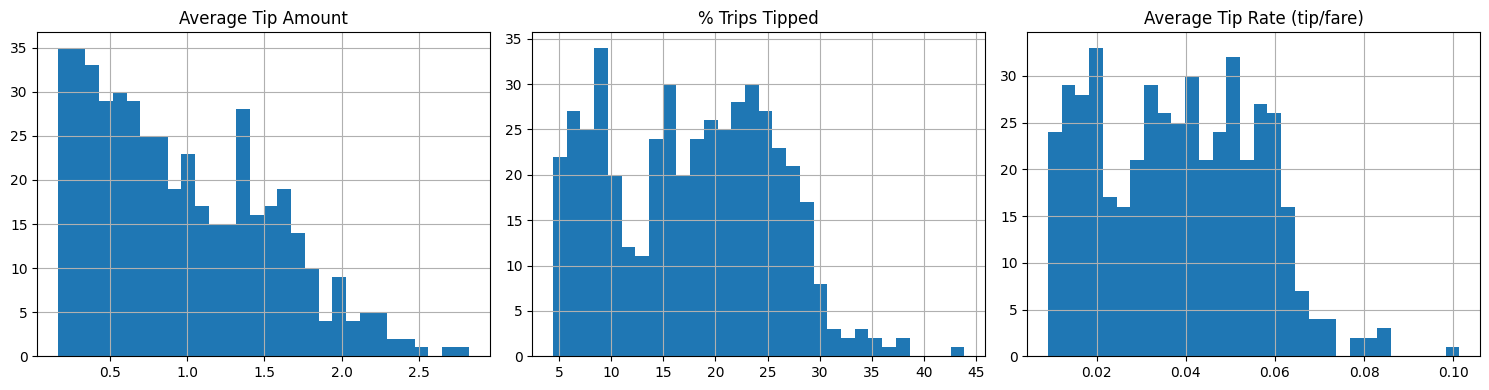

          avg_tip  pct_tipped  avg_tip_rate
count  468.000000  468.000000    468.000000
mean     0.960905   17.663802      0.038100
std      0.570050    7.827082      0.017592
min      0.163886    4.401216      0.009051
25%      0.470490   10.373537      0.021511
50%      0.849686   17.851217      0.037860
75%      1.377950   23.711678      0.051370
max      2.827395   43.883749      0.101395


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

final_clean['avg_tip'].hist(ax=axes[0], bins=30)
axes[0].set_title('Average Tip Amount')

final_clean['pct_tipped'].hist(ax=axes[1], bins=30)
axes[1].set_title('% Trips Tipped')

final_clean['avg_tip_rate'].hist(ax=axes[2], bins=30)
axes[2].set_title('Average Tip Rate (tip/fare)')

plt.tight_layout()
plt.show()

print(final_clean[['avg_tip', 'pct_tipped', 'avg_tip_rate']].describe())

#use pct_tipped as primary outcome and avg_tip_rate as supplement


# check for multicollinearity

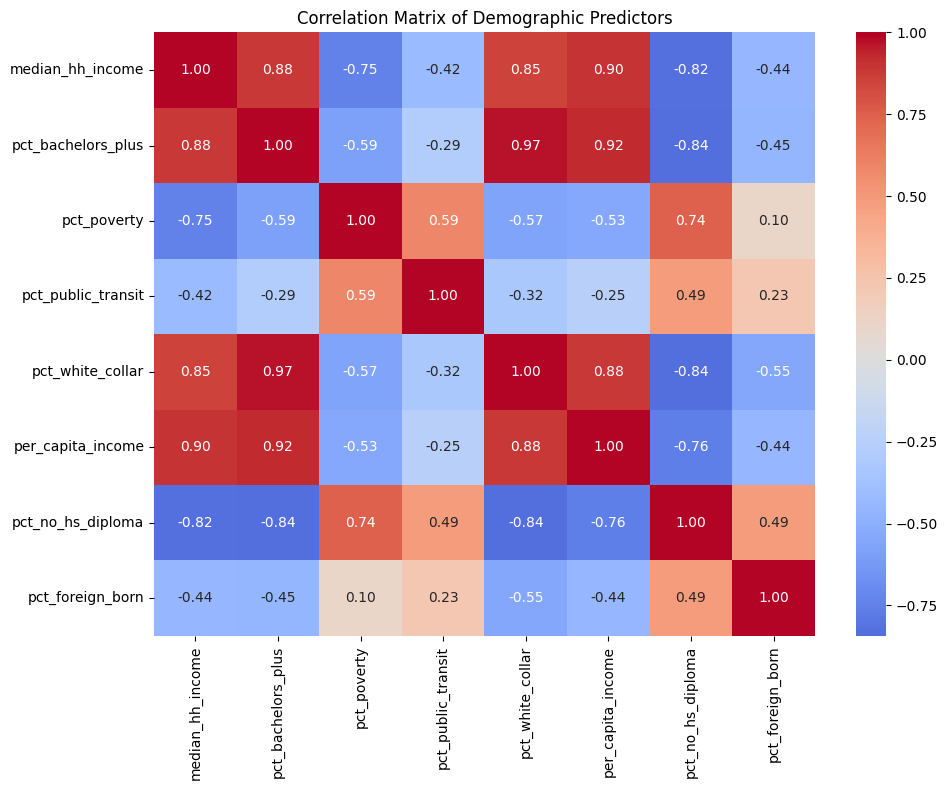

In [8]:
import seaborn as sns

predictors = ['median_hh_income', 'pct_bachelors_plus', 'pct_poverty', 
              'pct_public_transit', 'pct_white_collar', 'per_capita_income',
              'pct_no_hs_diploma', 'pct_foreign_born']

corr_matrix = final_clean[predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Matrix of Demographic Predictors')
plt.tight_layout()
plt.show()

In [ ]:
predictors_final = [
    'median_hh_income',    # income
    'pct_bachelors_plus',  # education
    'pct_poverty',         # poverty
    'pct_public_transit',  # transit dependency
    'pct_foreign_born',    # immigrant share
    'service'              # Uber vs Lyft
]

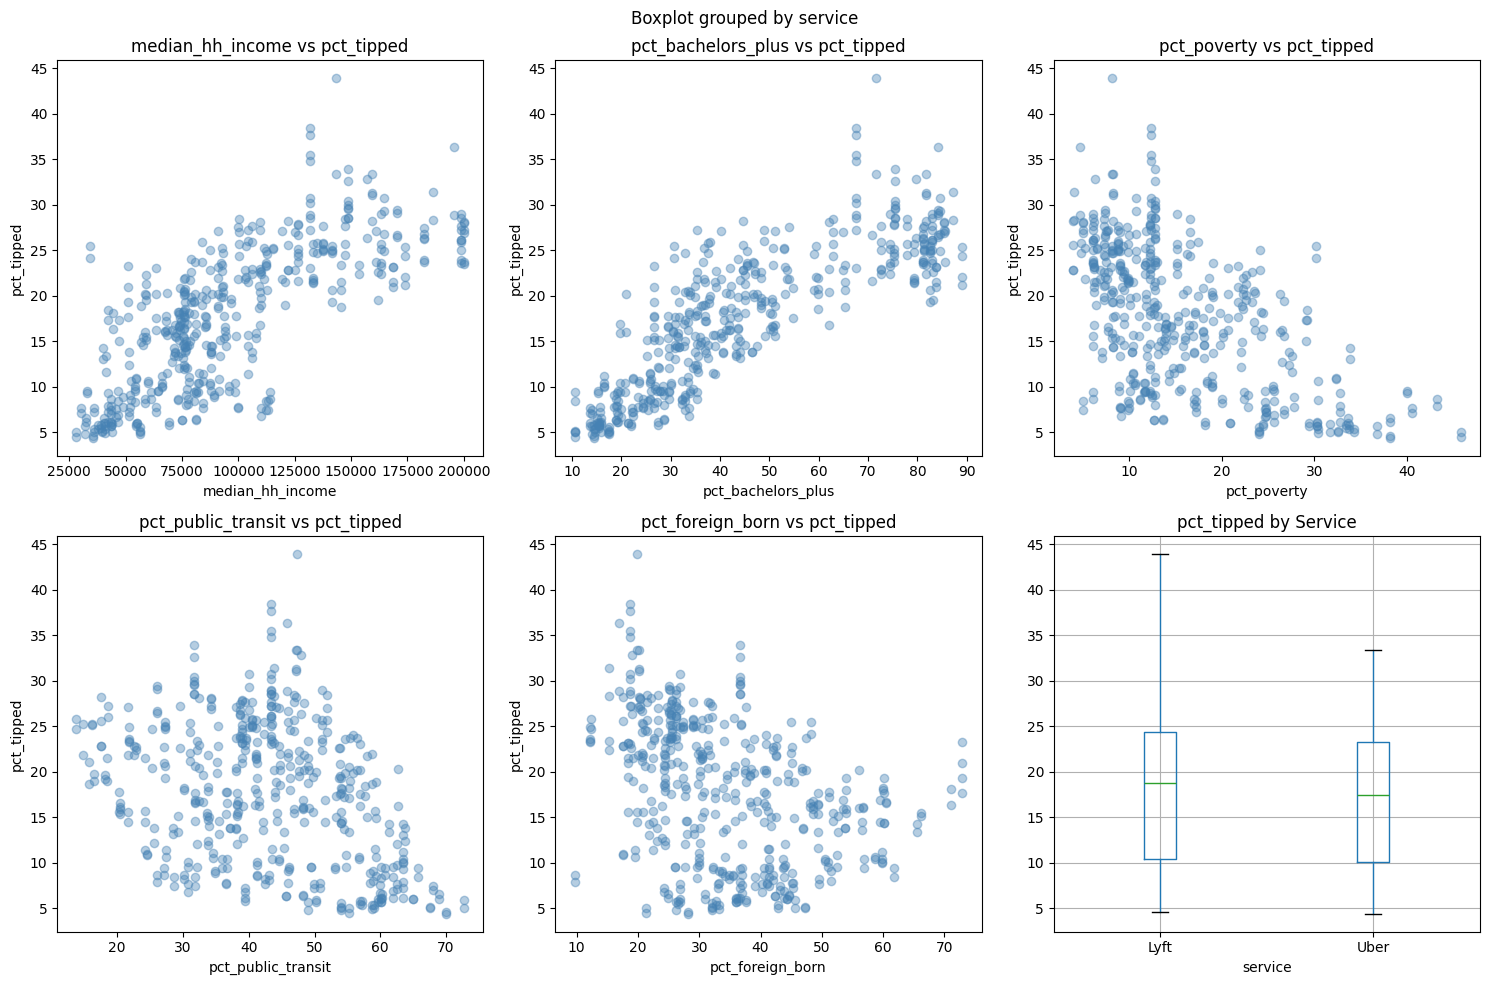

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

predictors_to_plot = ['median_hh_income', 'pct_bachelors_plus', 
                      'pct_poverty', 'pct_public_transit', 'pct_foreign_born']

for i, var in enumerate(predictors_to_plot):
    axes[i].scatter(final_clean[var], final_clean['pct_tipped'], 
                    alpha=0.4, color='steelblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('pct_tipped')
    axes[i].set_title(f'{var} vs pct_tipped')

# Use last subplot for Uber vs Lyft boxplot
final_clean.boxplot(column='pct_tipped', by='service', ax=axes[5])
axes[5].set_title('pct_tipped by Service')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Define predictors and outcome
X = final_clean[['median_hh_income', 'pct_bachelors_plus', 
                  'pct_poverty', 'pct_public_transit', 
                  'pct_foreign_born', 'service']]

y = final_clean['pct_tipped']

# Convert service to dummy variable (Uber = 1, Lyft = 0)
X = pd.get_dummies(X, columns=['service'], drop_first=True)

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print(X_train.columns.tolist())

Training set: (374, 6)
Test set: (94, 6)
['median_hh_income', 'pct_bachelors_plus', 'pct_poverty', 'pct_public_transit', 'pct_foreign_born', 'service_Uber']


In [11]:
print(final_clean['service'].value_counts())
print()
print('Train:')
print(X_train['service_Uber'].value_counts())
print()
print('Test:')
print(X_test['service_Uber'].value_counts())

service
Lyft    234
Uber    234
Name: count, dtype: int64

Train:
service_Uber
False    194
True     180
Name: count, dtype: int64

Test:
service_Uber
True     54
False    40
Name: count, dtype: int64


In [14]:
# Convert boolean to integer
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Now try again
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             pct_tipped   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     163.8
Date:                Sun, 03 May 2026   Prob (F-statistic):          1.48e-100
Time:                        19:19:26   Log-Likelihood:                -1063.5
No. Observations:                 374   AIC:                             2141.
Df Residuals:                     367   BIC:                             2168.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 12.1018      1

In [15]:
# Redefine X without insignificant variables
X2 = final_clean[['pct_bachelors_plus', 'pct_poverty', 
                   'pct_public_transit', 'service']]

y = final_clean['pct_tipped']

# Convert service to dummy
X2 = pd.get_dummies(X2, columns=['service'], drop_first=True)
X2 = X2.astype(float)

# Split again
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

# Fit model
X2_train_sm = sm.add_constant(X2_train)
model2 = sm.OLS(y_train, X2_train_sm).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             pct_tipped   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     243.4
Date:                Sun, 03 May 2026   Prob (F-statistic):          4.28e-102
Time:                        19:21:12   Log-Likelihood:                -1065.4
No. Observations:                 374   AIC:                             2141.
Df Residuals:                     369   BIC:                             2161.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  9.3438      1

- For every 1% increase in college-educated residents in a zone, the tipping rate goes up by 0.27 percentage points. 
- Zones where more people commute by transit have lower tipping rates. 
- After controlling for neighborhood demographics, Uber zones have 0.89 percentage points lower tipping rate than Lyft zones. This suggests something about Uber's app UX or customer base beyond just location. hypothetical zone with 0% college educated, 0% poverty, 0% transit commuters using Lyft would have a 9.34% tipping rate as a baseline.
- Overall: R² = 0.725 — the model explains 72.5% of tipping variation across zones.


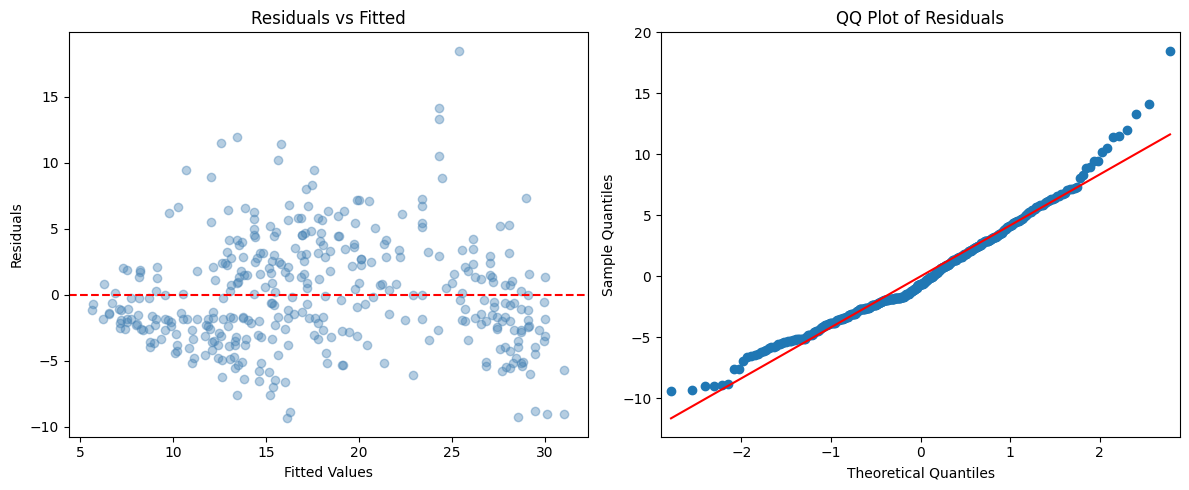

In [16]:
# Get residuals and fitted values
fitted = model2.fittedvalues
residuals = model2.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# QQ plot
import statsmodels.graphics.gofplots as sm_plots
sm_plots.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('QQ Plot of Residuals')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predict on test set
X2_test_sm = sm.add_constant(X2_test)
y_pred = model2.predict(X2_test_sm)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Test RMSE: {rmse:.3f}')
print(f'Test R²: {r2:.3f}')

Test RMSE: 4.142
Test R²: 0.664


## Next Steps

### 1. Strengthen the Model with Additional Predictors
The current model explains 72.5% of variance in tipping rates using education, 
poverty, transit dependency, and service (Uber vs Lyft). To build a more complete 
picture of socioeconomic drivers of tipping behavior, the following variables will 
be added:

- **Age distribution** — median age or % over 65 from ACS Demographic file
- **Race/ethnicity composition** — % white, % Black, % Hispanic, % Asian from ACS
- **Average household size** — already in current dataset
- **Unemployment rate** — from ACS Economic file
- **Rent vs ownership rate** — from ACS Housing file

These variables will require downloading the Demographic and Housing ACS files 
from the NYC Planning website and merging them into the existing zone_demographics 
table using the same GeoID join key.

### 2. Re-run Assumption Checks
After adding new predictors, re-check:
- Correlation matrix for multicollinearity
- Residuals vs fitted plot for homoscedasticity
- QQ plot for normality of residuals

### 3. Build a Prediction Tool
Using the final model, build a prediction framework where a user inputs a 
PULocationID and the model returns the predicted percentage of trips that 
will be tipped in that pickup zone. This will serve as the practical 
application of the regression model.

### 4. Robustness Check
Re-run the final model using `avg_tip_rate` as an alternative outcome variable 
to confirm findings are consistent across different measures of tipping behavior.

### 5. Separate Uber and Lyft Models
Fit separate regression models for Uber and Lyft to see if socioeconomic 
factors affect tipping differently across the two services, rather than 
just using service as a control variable.